# 01 - Load Marmousi
Notebook-first entry: load Marmousi velocity (`.npy` or `.segy`), check stats, and visualize.

In [1]:
from pathlib import Path
import sys
import numpy as np

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'src').exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.io import load_yaml, seed_everything, resolve_path
from src.data import load_marmousi_vp, model_stats
from src.utils.viz import plot_velocity_model

CONFIG_FILE = 'marmousi_acoustic.yaml'  # or 'fastdev.yaml'
cfg = load_yaml(PROJECT_ROOT / 'configs' / CONFIG_FILE)
seed_everything(int(cfg['seed']))
print('Project root:', PROJECT_ROOT)

Project root: /root/FWI/pinn_acoustic_fwi


Vp shape: (176, 681)
{'vp_min': 1028.0, 'vp_max': 4700.0, 'vp_mean': 2672.000732421875, 'vp_std': 975.6336669921875, 'nz': 176, 'nx': 681}


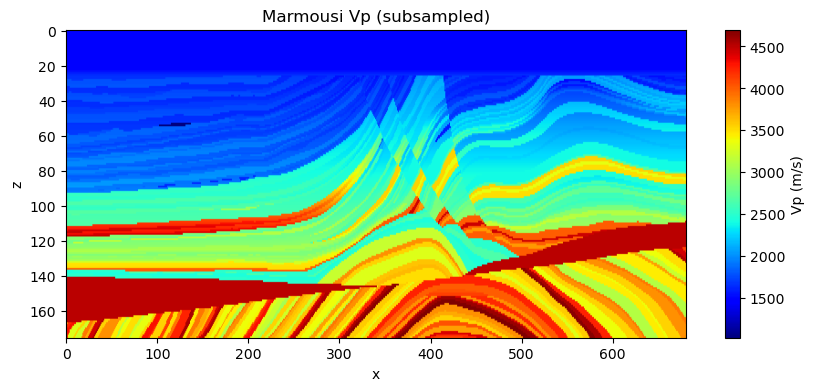

In [2]:
vp_path = resolve_path(PROJECT_ROOT, cfg['data']['vp_path'])
vp = load_marmousi_vp(vp_path, subsample=int(cfg['model']['subsample']))
print('Vp shape:', vp.shape)
print(model_stats(vp))
plot_velocity_model(vp, title='Marmousi Vp (subsampled)')

In [3]:
out = PROJECT_ROOT / 'data' / 'processed' / 'marmousi_vp_subsampled.npy'
out.parent.mkdir(parents=True, exist_ok=True)
np.save(out, vp.astype(np.float32))
print('Saved:', out)

Saved: /root/FWI/pinn_acoustic_fwi/data/processed/marmousi_vp_subsampled.npy
